# Imports

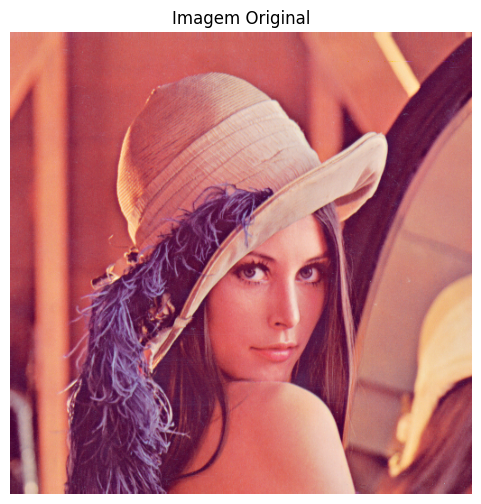

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upe a imagem desejada no collab e troque o nome/pathing
# Link da Imagem: https://gist.github.com/anishLearnsToCode/120f0ae1cc457b68a814f4697cd8deab
caminho_imagem = "lenna.png"

img_bgr = cv2.imread(caminho_imagem)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def show_image(image, title="Imagem", cmap=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

show_image(img_rgb, "Imagem Original")

# Questão 3

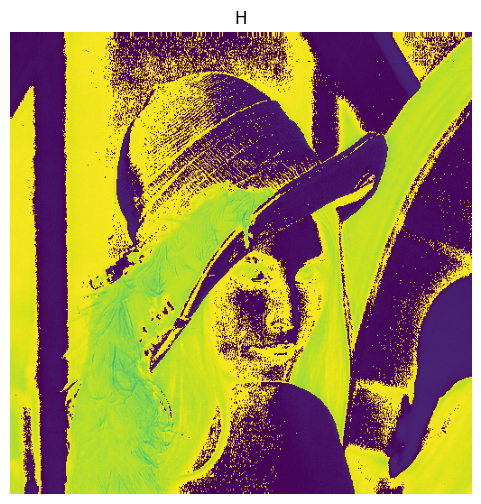

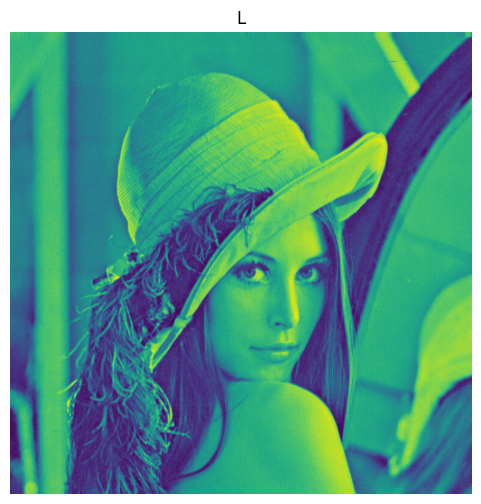

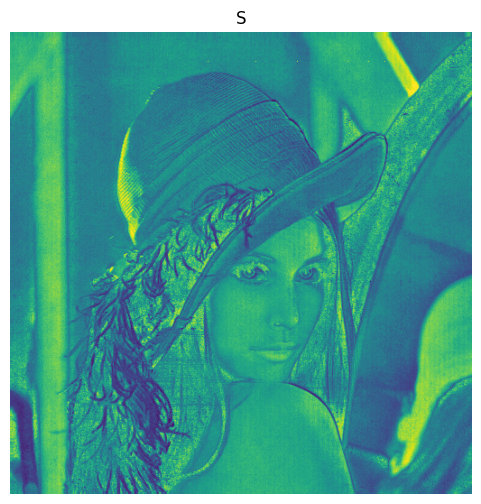

True

In [ ]:
def rgb_para_hls(img_rgb):
    # Converte a imagem de uint8 (valores de 0 a 255)
    # para float32 com valores normalizados entre 0 e 1
    img = img_rgb.astype(np.float32) / 255.0

    # Separa os canais de cor da imagem RGB
    R = img[:, :, 0]  # Canal vermelho
    G = img[:, :, 1]  # Canal verde
    B = img[:, :, 2]  # Canal azul

    # Calcula, para cada pixel, o maior valor entre R, G e B
    maximo = np.maximum(np.maximum(R, G), B)

    # Calcula, para cada pixel, o menor valor entre R, G e B
    minimo = np.minimum(np.minimum(R, G), B)

    # Calcula a luminosidade L
    # No modelo HLS, a luminosidade é a média entre o maior e o menor canal
    L = (maximo + minimo) / 2.0

    # Calcula a diferença entre o maior e o menor valor RGB
    # Essa diferença indica o quanto existe de variação de cor no pixel
    delta = maximo - minimo

    # Inicializa a matriz de matiz H com zeros
    H = np.zeros_like(L)

    # Inicializa a matriz de saturação S com zeros
    S = np.zeros_like(L)

    # Cria uma máscara para identificar pixels que possuem cor
    # Quando delta é zero, significa que R = G = B, ou seja, o pixel é cinza
    mask_delta = delta != 0

    # Máscara para pixels com luminosidade menor que 0.5
    mask_l_menor = (L < 0.5) & mask_delta

    # Máscara para pixels com luminosidade maior ou igual a 0.5
    mask_l_maior = (L >= 0.5) & mask_delta

    # Calcula a saturação para pixels com L < 0.5
    S[mask_l_menor] = (
        delta[mask_l_menor] /
        (maximo[mask_l_menor] + minimo[mask_l_menor])
    )

    # Calcula a saturação para pixels com L >= 0.5
    S[mask_l_maior] = (
        delta[mask_l_maior] /
        (2.0 - maximo[mask_l_maior] - minimo[mask_l_maior])
    )

    # Máscara para pixels em que o canal vermelho é o maior valor
    mask_r = (maximo == R) & mask_delta

    # Máscara para pixels em que o canal verde é o maior valor
    mask_g = (maximo == G) & mask_delta

    # Máscara para pixels em que o canal azul é o maior valor
    mask_b = (maximo == B) & mask_delta

    # Calcula a matiz H quando o vermelho é o canal dominante
    H[mask_r] = 60 * (
        (G[mask_r] - B[mask_r]) / delta[mask_r]
    )

    # Calcula a matiz H quando o verde é o canal dominante
    H[mask_g] = 60 * (
        2 + (B[mask_g] - R[mask_g]) / delta[mask_g]
    )

    # Calcula a matiz H quando o azul é o canal dominante
    H[mask_b] = 60 * (
        4 + (R[mask_b] - G[mask_b]) / delta[mask_b]
    )

    # Caso algum valor de H fique negativo,
    # soma 360 para colocá-lo no intervalo de 0 a 360 graus
    H[H < 0] += 360

    return H, L, S


# Chama a função para converter a imagem RGB para HLS
H, L, S = rgb_para_hls(img_rgb)

# Converte o canal H para uma imagem de 8 bits
# H varia de 0 a 360, então é escalado para 0 a 255
H_image = (H / 360 * 255).astype(np.uint8)

# Converte o canal L para uma imagem de 8 bits
# L varia de 0 a 1, então é multiplicado por 255
L_image = (L * 255).astype(np.uint8)

# Converte o canal S para uma imagem de 8 bits
# S varia de 0 a 1, então é multiplicado por 255
S_image = (S * 255).astype(np.uint8)

show_image(H_image, "H")
show_image(L_image, "L")
show_image(S_image, "S")

# Questão 4

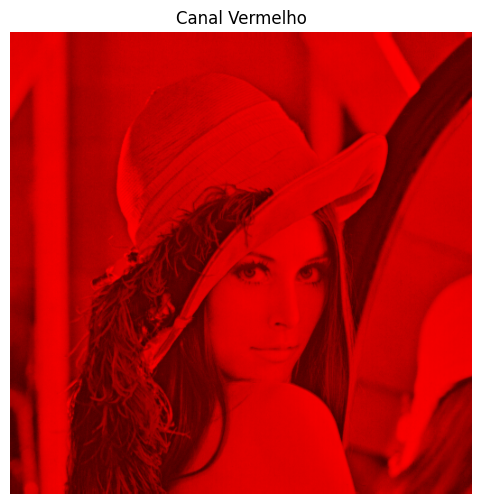

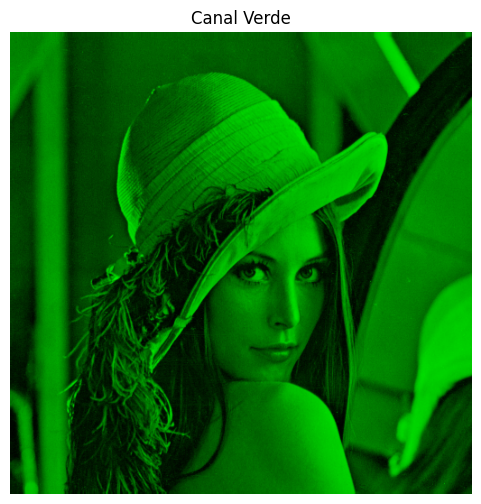

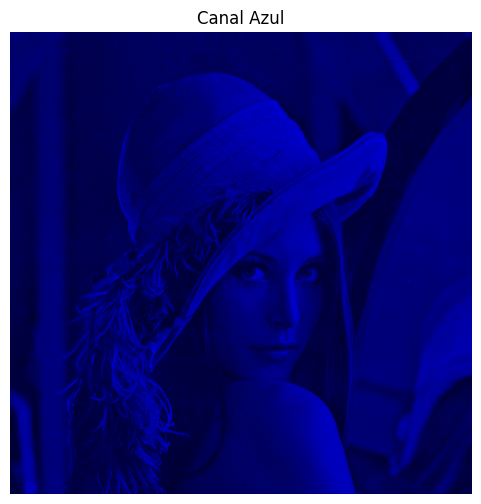

In [ ]:
# Separar canais
R = img_rgb.copy()
G = img_rgb.copy()
B = img_rgb.copy()

# Zerar os outros canais
R[:, :, 1] = 0  # G
R[:, :, 2] = 0  # B

G[:, :, 0] = 0  # R
G[:, :, 2] = 0  # B

B[:, :, 0] = 0  # R
B[:, :, 1] = 0  # G

show_image(R, "Canal Vermelho")
show_image(G, "Canal Verde")
show_image(B, "Canal Azul")

# Questão 5

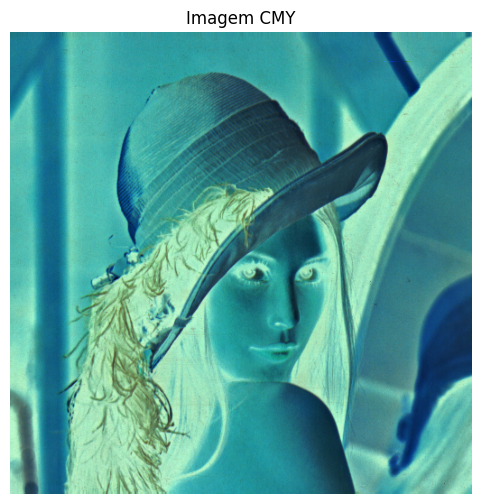

In [ ]:
def rgb_para_cmy(img_rgb):
    # Converte a imagem de uint8 (0 a 255) para float32 (0.0 a 1.0)
    img = img_rgb.astype(np.float32) / 255.0

    # Calcula os canais CMY a partir dos canais RGB
    # CMY é o modelo complementar do RGB:
    # Ciano (C) = 1 - Vermelho (R)
    C = 1 - img[:, :, 0]
    # Magenta (M) = 1 - Verde (G)
    M = 1 - img[:, :, 1]
    # Amarelo (Y) = 1 - Azul (B)
    Y = 1 - img[:, :, 2]

    # Junta os canais C, M, Y em uma única imagem tridimensional
    img_cmy = np.stack((C, M, Y), axis=2)

    return img_cmy

img_cmy = rgb_para_cmy(img_rgb)
show_image(img_cmy, "Imagem CMY", cmap='gray')

# Questão 6

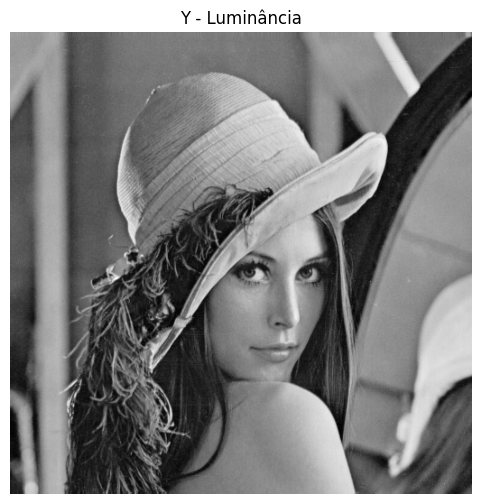

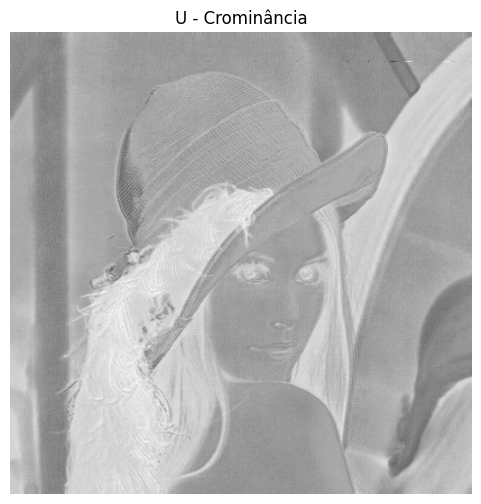

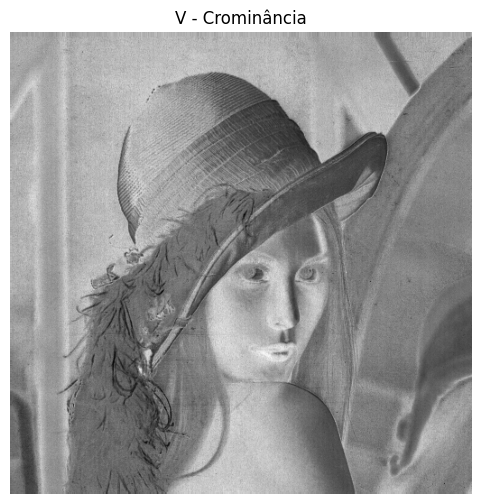

In [ ]:
def rgb_para_yuv(img_rgb):
    # Converte a imagem de uint8 (0-255) para float32 (0.0-1.0)
    img = img_rgb.astype(np.float32) / 255.0

    # Separa os canais RGB
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    # Calcula Y, U e V usando a fórmula padrão de conversão RGB -> YUV
    # Y = luminância (brilho), U e V = crominância (informação de cor)
    Y = 0.299 * R + 0.587 * G + 0.114 * B
    U = -0.147 * R - 0.289 * G + 0.436 * B
    V = 0.615 * R - 0.515 * G - 0.100 * B

    return Y, U, V


# Converte a imagem RGB para YUV
Y, U, V = rgb_para_yuv(img_rgb)

# Normalização para exibição em imagens de 8 bits (0-255)
# Y já está entre 0 e 1, basta multiplicar por 255
Y_img = (Y * 255).astype(np.uint8)

# U varia aproximadamente entre -0.436 e +0.436
# Normalizamos para 0-255 para visualização
U_img = ((U + 0.436) / (0.436 * 2) * 255).astype(np.uint8)

# V varia aproximadamente entre -0.615 e +0.615
# Normalizamos para 0-255 para visualização
V_img = ((V + 0.615) / (0.615 * 2) * 255).astype(np.uint8)

show_image(Y_img, "Y - Luminância", cmap="gray")
show_image(U_img, "U - Crominância", cmap="gray")
show_image(V_img, "V - Crominância", cmap="gray")

# Questão 7

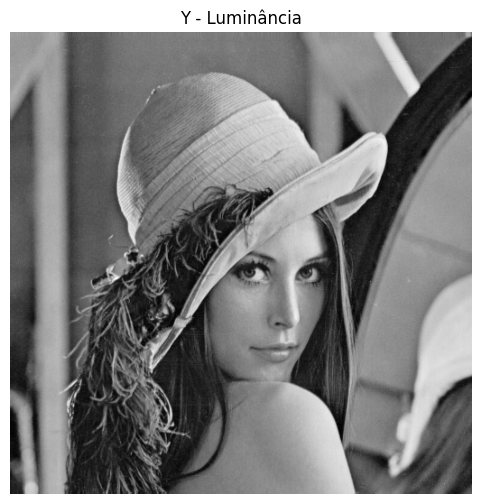

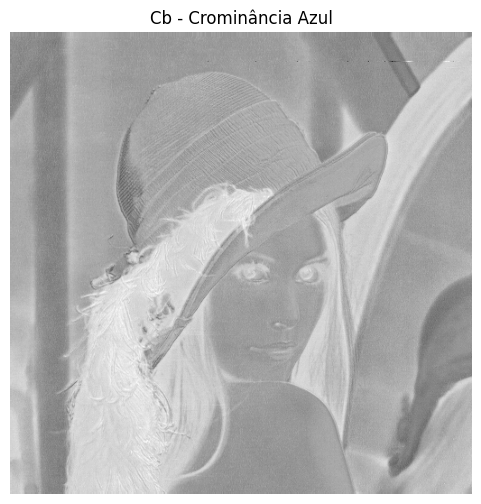

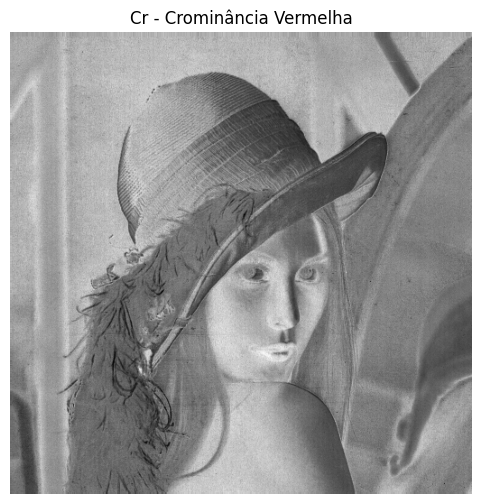

In [ ]:
def rgb_para_ycbcr(img_rgb):
    # Converte a imagem de uint8 (0-255) para float32 (0.0-1.0)
    img = img_rgb.astype(np.float32) / 255.0

    # Separa os canais RGB
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    # Calcula Y, Cb e Cr usando a fórmula padrão de conversão RGB -> YCbCr
    # Y  = luminância (brilho)
    # Cb = crominância azul (diferença entre azul e luminância)
    # Cr = crominância vermelha (diferença entre vermelho e luminância)
    Y = 0.299 * R + 0.587 * G + 0.114 * B
    Cb = -0.168736 * R - 0.331264 * G + 0.5 * B + 0.5
    Cr = 0.5 * R - 0.418688 * G - 0.081312 * B + 0.5

    return Y, Cb, Cr


# Converte a imagem RGB para YCbCr
Y, Cb, Cr = rgb_para_ycbcr(img_rgb)

# Normalização para exibição em imagens de 8 bits (0-255)
Y_img = (Y * 255).astype(np.uint8)
Cb_img = (Cb * 255).astype(np.uint8)
Cr_img = (Cr * 255).astype(np.uint8)

show_image(Y_img, "Y - Luminância", cmap="gray")
show_image(Cb_img, "Cb - Crominância Azul", cmap="gray")
show_image(Cr_img, "Cr - Crominância Vermelha", cmap="gray")

# Questão 8


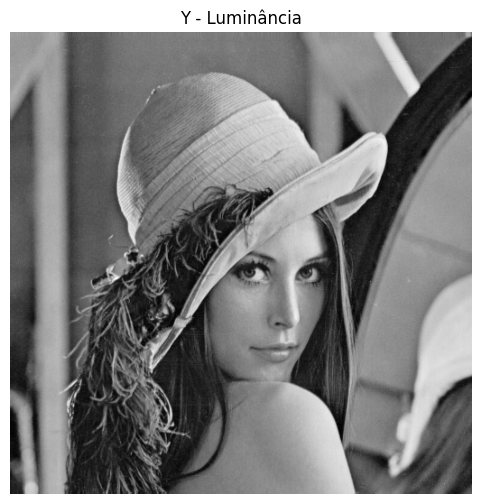

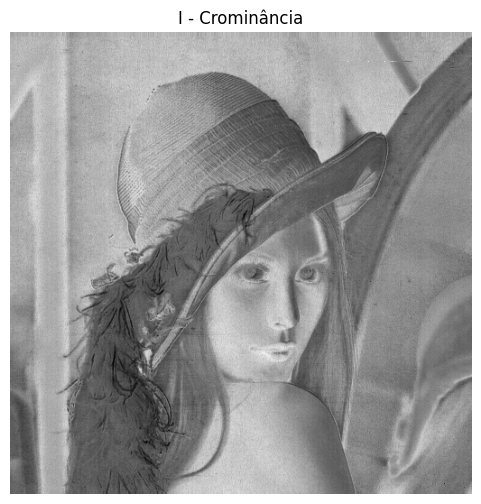

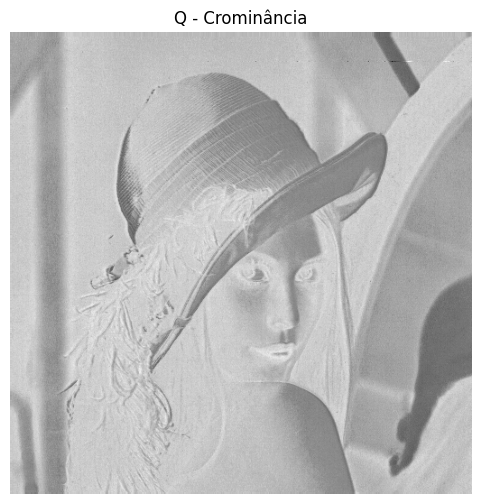

In [ ]:
def rgb_para_yiq(img_rgb):
    # Converte a imagem de uint8 (0-255) para float32 (0.0-1.0)
    img = img_rgb.astype(np.float32) / 255.0

    # Separa os canais RGB
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    # Calcula Y, I e Q usando a fórmula padrão de conversão RGB -> YIQ
    # Y = luminância (brilho)
    # I = crominância em torno do eixo laranja-ciano
    # Q = crominância em torno do eixo roxo-verde
    Y = 0.299 * R + 0.587 * G + 0.114 * B
    I = 0.596 * R - 0.274 * G - 0.322 * B
    Q = 0.211 * R - 0.523 * G + 0.312 * B

    return Y, I, Q


# Converte a imagem RGB para YIQ
Y, I, Q = rgb_para_yiq(img_rgb)

# Normalização para exibição em imagens de 8 bits (0-255)
# Y já está entre 0 e 1, basta multiplicar por 255
Y_img = (Y * 255).astype(np.uint8)

# I varia aproximadamente entre -0.5957 e +0.5957
# Normalização para 0-255 para visualização
I_img = ((I + 0.5957) / (2 * 0.5957) * 255).astype(np.uint8)

# Q varia aproximadamente entre -0.5226 e +0.5226
# Normalização para 0-255 para visualização
Q_img = ((Q + 0.5226) / (2 * 0.5226) * 255).astype(np.uint8)

show_image(Y_img, "Y - Luminância", cmap="gray")
show_image(I_img, "I - Crominância", cmap="gray")
show_image(Q_img, "Q - Crominância", cmap="gray")

# Questão 9

Informe o valor de γ (ex: 2.2): 2.2


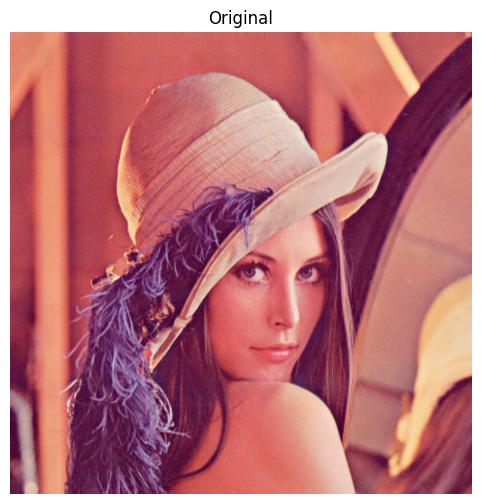

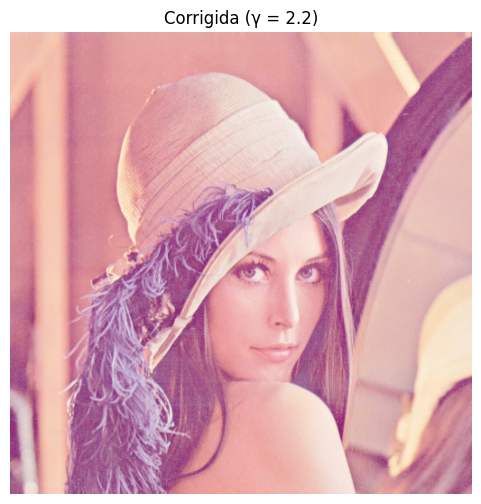

In [ ]:
gamma = float(input("Informe o valor de γ (ex: 2.2): "))

def aplicacao_gama(img_rgb, gamma):
    # Converte a imagem de uint8 (0-255) para float32 (0.0-1.0)
    img_float = img_rgb.astype(np.float32) / 255.0

    # Aplica a correção gama: I_corrigido = I_original^(1/γ)
    # Essa operação ajusta o brilho da imagem de acordo com o valor de gamma
    img_corrigida = np.power(img_float, 1.0 / gamma)

    # Converte de volta para uint8 (0-255)
    img_corrigida_uint8 = (img_corrigida * 255).astype(np.uint8)

    return img_corrigida_uint8

img_rgb_corrigida = aplicacao_gama(img_rgb, gamma)

show_image(img_rgb, f"Original")
show_image(img_rgb_corrigida, f"Corrigida (γ = {gamma})")